In [6]:
import numpy as np
import matplotlib.pyplot as plt

from cochleasim.models.params_loader import CAT_PARAMS
from cochleasim.models.cochlear_model import (
    impedance_Z1, impedance_Z2, impedance_Z3, impedance_Z4, partition_impedance
)

p = CAT_PARAMS

def Zp_pasiva(x, omega, params):
    """Zp con gamma=0 (sin elemento activo)."""
    Z1v = impedance_Z1(x, omega, params)
    Z2v = impedance_Z2(x, omega, params)
    Z3v = impedance_Z3(x, omega, params)
    return (params.g/params.b) * (Z1v + Z2v*Z3v/(Z2v+Z3v))

def L0(x, omega, params):
    """Ganancia de lazo normalizada: Zp(gamma) = Zp_pasiva * (1 - gamma*L0).
    OJO: con este convenio, la inestabilidad esta en fase=0 grados, NO en -180
    como en un lazo de realimentacion negativa clasico -- viene del signo menos
    con el que aparece gamma en la formula de Zp del paper (ec. 12)."""
    Z2v = impedance_Z2(x, omega, params)
    Z3v = impedance_Z3(x, omega, params)
    Z4v = impedance_Z4(x, omega, params)
    return (params.g/params.b) * Z2v*Z4v / ((Z2v+Z3v) * Zp_pasiva(x, omega, params))

freqs = np.logspace(1, 5, 500)

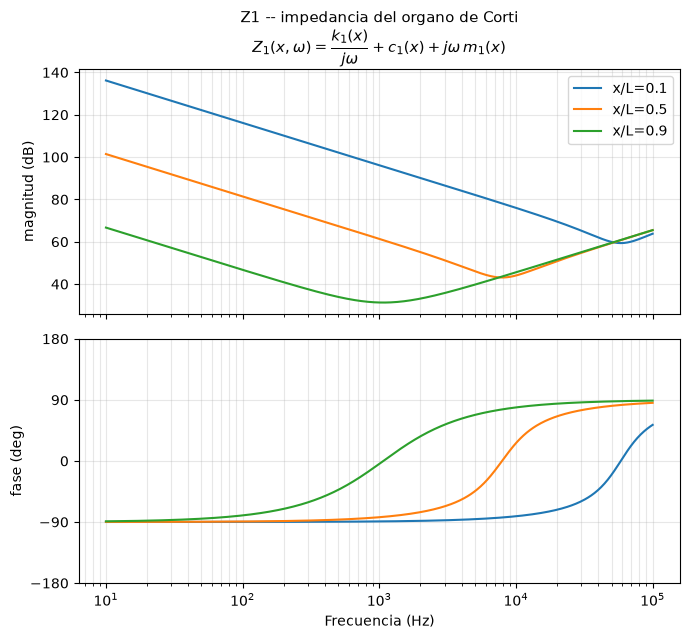

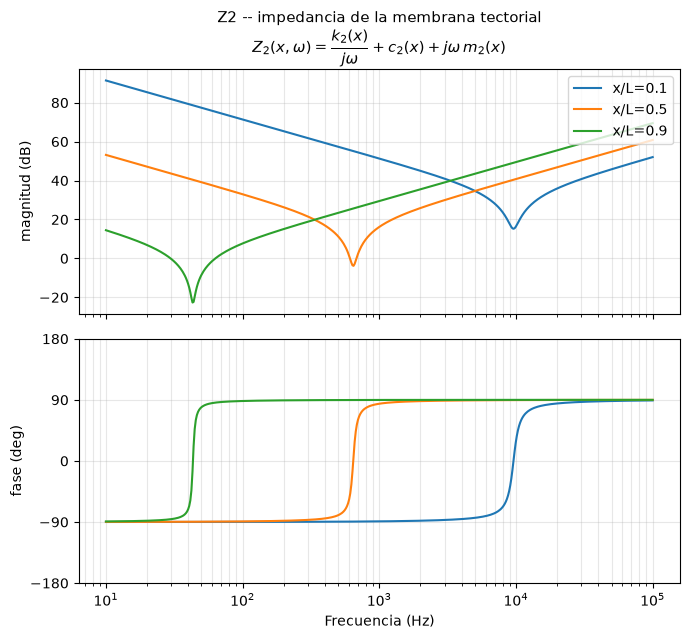

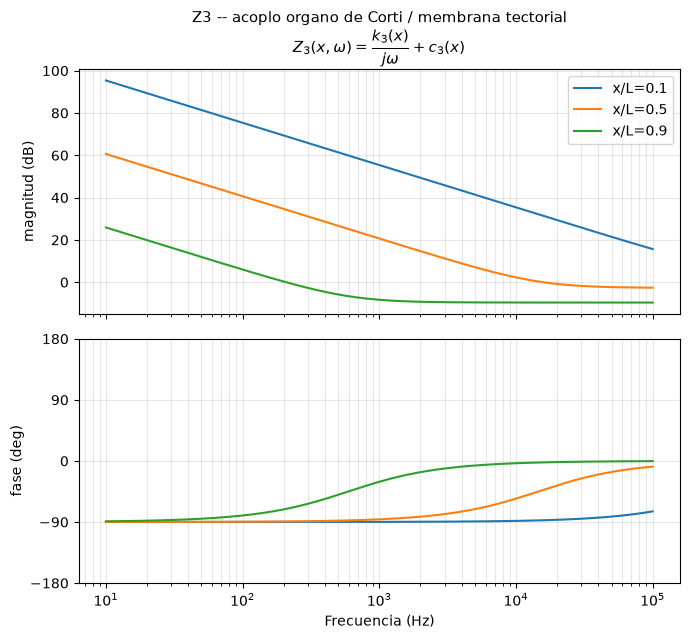

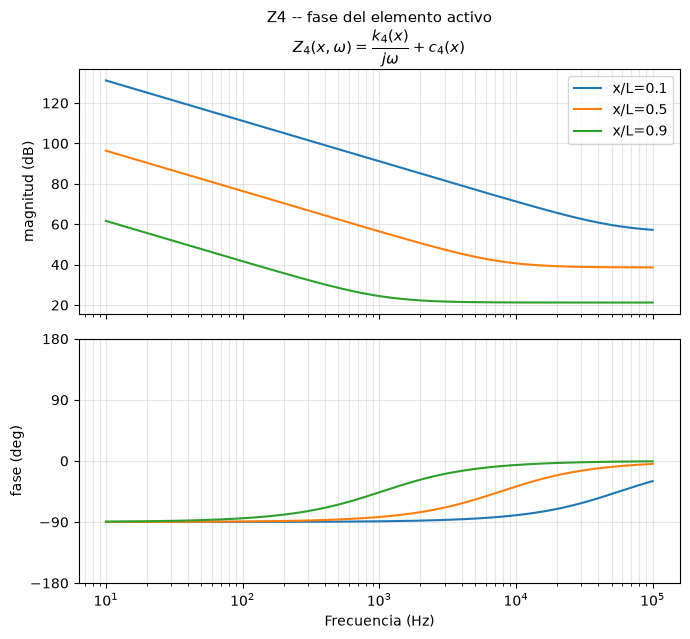

In [7]:
formulas = {
    "Z1": r"$Z_1(x,\omega) = \dfrac{k_1(x)}{j\omega} + c_1(x) + j\omega\, m_1(x)$",
    "Z2": r"$Z_2(x,\omega) = \dfrac{k_2(x)}{j\omega} + c_2(x) + j\omega\, m_2(x)$",
    "Z3": r"$Z_3(x,\omega) = \dfrac{k_3(x)}{j\omega} + c_3(x)$",
    "Z4": r"$Z_4(x,\omega) = \dfrac{k_4(x)}{j\omega} + c_4(x)$",
}
bloques = [
    ("Z1 -- impedancia del organo de Corti", impedance_Z1, "Z1", "k1", "c1", "m1"),
    ("Z2 -- impedancia de la membrana tectorial", impedance_Z2, "Z2", "k2", "c2", "m2"),
    ("Z3 -- acoplo organo de Corti / membrana tectorial", impedance_Z3, "Z3", "k3", "c3", None),
    ("Z4 -- fase del elemento activo", impedance_Z4, "Z4", "k4", "c4", None),
]
xs_ejemplo = [0.1, 0.5, 0.9]

for nombre, Zfun, key, nk, nc, nm in bloques:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6.5), sharex=True)  # +0.5 de alto por la 2a linea del titulo
    for xL in xs_ejemplo:
        xt = xL * p.L
        vals = np.array([Zfun(xt, 2*np.pi*f, p) for f in freqs])
        ax1.semilogx(freqs, 20*np.log10(np.abs(vals)), label=f"x/L={xL}")
        ax2.semilogx(freqs, np.angle(vals, deg=True), label=f"x/L={xL}")

    ax1.set_title(nombre + "\n" + formulas[key], fontsize=11)   # <-- formula como 2a linea del titulo
    ax1.set_ylabel("magnitud (dB)"); ax1.legend(loc='upper right'); ax1.grid(True, which='both', alpha=0.3)
    ax2.set_ylabel("fase (deg)"); ax2.set_ylim(-180, 180); ax2.set_yticks([-180,-90,0,90,180])
    ax2.set_xlabel("Frecuencia (Hz)"); ax2.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()



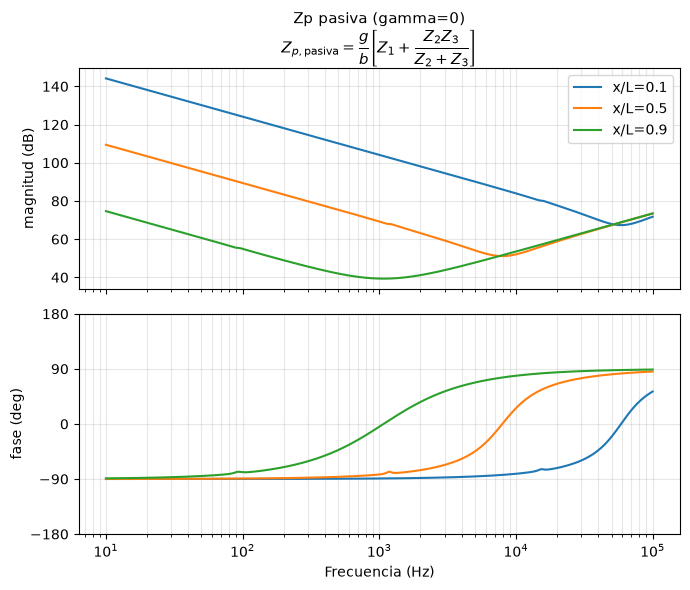

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7,6), sharex=True)
for xL in [0.1, 0.5, 0.9]:
    xt = xL * p.L
    vals = np.array([Zp_pasiva(xt, 2*np.pi*f, p) for f in freqs])
    ax1.semilogx(freqs, 20*np.log10(np.abs(vals)), label=f"x/L={xL}")
    ax2.semilogx(freqs, np.angle(vals, deg=True), label=f"x/L={xL}")
formula_zp = r"$Z_{p,\mathrm{pasiva}} = \dfrac{g}{b}\left[Z_1 + \dfrac{Z_2 Z_3}{Z_2+Z_3}\right]$"
ax1.set_title("Zp pasiva (gamma=0)\n" + formula_zp, fontsize=11)
ax1.set_ylabel("magnitud (dB)"); ax1.legend(); ax1.grid(True, which='both', alpha=0.3)
ax2.set_ylabel("fase (deg)"); ax2.set_ylim(-180,180); ax2.set_yticks([-180,-90,0,90,180])
ax2.set_xlabel("Frecuencia (Hz)"); ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

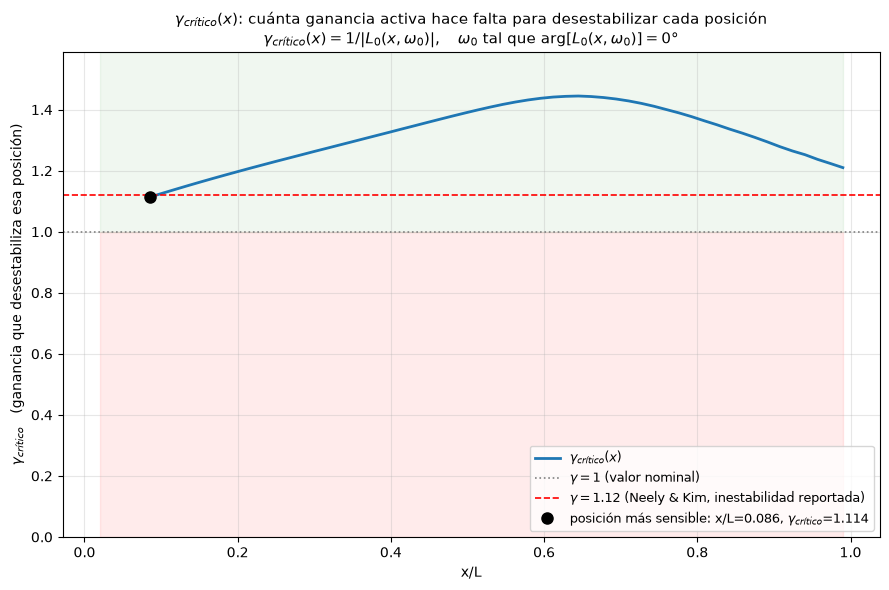

Posición más crítica: x/L=0.0858, gamma_crítico=1.1137
Puntos sin cruce de fase 0° en el rango probado: 4 de 60


In [9]:
def gamma_critico(xL, freqs, p):
    xt = xL * p.L
    L0_vals = np.array([L0(xt, 2*np.pi*f, p) for f in freqs])
    fase = np.angle(L0_vals, deg=True)
    mag = np.abs(L0_vals)
    cruces = np.where(np.diff(np.sign(fase)) != 0)[0]
    return np.inf if len(cruces) == 0 else 1/mag[cruces].max()

freqs_finos = np.logspace(1, 4.5, 4000)
xs = np.linspace(0.02, 0.99, 60)
gammas = np.array([gamma_critico(xL, freqs_finos, p) for xL in xs])
i_min = np.argmin(gammas)
xL_critico = xs[i_min]
gamma_critico_val = gammas[i_min]

gammas_finitos = gammas[np.isfinite(gammas)]
techo = gammas_finitos.max() * 1.1

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(xs, gammas, color='tab:blue', linewidth=2, label=r'$\gamma_{crítico}(x)$')
ax.fill_between(xs, 0, 1.0, color='red', alpha=0.08)
ax.fill_between(xs, 1.0, techo, color='green', alpha=0.06)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.2, label=r'$\gamma=1$ (valor nominal)')
ax.axhline(1.12, color='r', linestyle='--', linewidth=1.2,
           label=r'$\gamma=1.12$ (Neely & Kim, inestabilidad reportada)')
ax.plot(xL_critico, gamma_critico_val, 'ko', markersize=8, zorder=5,
        label=f'posición más sensible: x/L={xL_critico:.3f}, ' + r'$\gamma_{crítico}$' + f'={gamma_critico_val:.3f}')

ax.set_xlabel("x/L")
ax.set_ylabel(r"$\gamma_{crítico}$   (ganancia que desestabiliza esa posición)")
ax.set_ylim(0, techo)

titulo = (r"$\gamma_{crítico}(x)$: cuánta ganancia activa hace falta para desestabilizar cada posición" + "\n" +
          r"$\gamma_{crítico}(x) = 1/|L_0(x,\omega_0)|,\quad \omega_0 \text{ tal que } \arg[L_0(x,\omega_0)]=0°$")
ax.set_title(titulo, fontsize=11)

ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Posición más crítica: x/L={xL_critico:.4f}, gamma_crítico={gamma_critico_val:.4f}")
print(f"Puntos sin cruce de fase 0° en el rango probado: {(~np.isfinite(gammas)).sum()} de {len(gammas)}")

In [10]:
m = margenes(xL_critico, np.logspace(1, 4.7, 3000), p)   # <-- usa la variable, no un numero suelto

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,7.3), sharex=True)
ax1.semilogx(m['freqs'], m['mag_db'])
ax1.axhline(0, color='k', linewidth=0.7)
ax1.axvline(m['f_gm'], color='r', linestyle=':',
            label=f"cruce fase 0° (f={m['f_gm']:.0f} Hz)\nmargen ganancia={m['gm_db']:.2f} dB")
ax1.axvline(m['f_pm'], color='g', linestyle=':', label=f"cruce |L0|=1 (f={m['f_pm']:.0f} Hz)")

formula_L0 = r"$L_0 = \dfrac{g}{b}\cdot\dfrac{Z_2 Z_4}{(Z_2+Z_3)\,Z_{p,\mathrm{pasiva}}}$"
ax1.set_title(f"L0 en x/L={xL_critico:.3f} -- posicion mas critica, calculada en la celda anterior\n"
              + formula_L0, fontsize=10)
ax1.set_ylabel("|L0| (dB)"); ax1.legend(fontsize=9); ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(m['freqs'], m['fase'])
ax2.axhline(0, color='k', linewidth=0.7, label='0° = criterio de inestabilidad aqui (no -180°)')
ax2.axvline(m['f_gm'], color='r', linestyle=':')
ax2.axvline(m['f_pm'], color='g', linestyle=':', label=f"margen de fase={m['pm_deg']:.1f}°")
ax2.set_ylim(-180,180); ax2.set_yticks([-180,-90,0,90,180])
ax2.set_ylabel("fase L0 (deg)"); ax2.set_xlabel("Frecuencia (Hz)")
ax2.legend(fontsize=9); ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Margen de ganancia: {m['gm_db']:.3f} dB  ->  gamma_critico={m['gamma_crit']:.4f}")
print(f"Margen de fase: {m['pm_deg']:.1f}°")

NameError: name 'margenes' is not defined